---
title: The Basic Perceptron
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina")
rng = np.random.default_rng(42)

### From the Artificial Neuron to the Perceptron

To continue, we keep the structure of the artificial neuron from the previous chapter but we adjust some concepts and the naming of some components.

In [2]:
class perceptron:
    """
    Docstring for perceptron
    """

    def __init__(self, n_inputs, threshold):
        """ Initialize perceptron
        Parameters
        ----------
        n_inputs :  integer Size of input vector
        threshold : float   Threshold for the perceptron to produce an output
        returns :   object  Perceptron object 
        """
        # the dentrite types become the weights
        self.weights = rng.choice([-1, 1], size=n_inputs)
        # postsynaptic potential becomes the weighted sum
        self.w_sum = 0
        self.threshold = threshold
        # action potential becomes the output
        self.output = 0

    def fire(self):
        """ Check weighted sum against threshold and generate output.
        Parameters
        ----------
        returns : int    0 or 1
        """
        if self.w_sum >= self.threshold:
            self.output = 1
            print("perceptron is firing")
            return 1
        else:
            self.output = 0
            print("perceptron is NOT firing")
            return 0

    def update(self, inputs):
        """ Update inputs, calculate weighted sum and generate output.
        Parameters
        ----------
        inputs : array_like     input vector  
        returns : int           0 or 1
        """
        self.w_sum = np.sum(np.multiply(self.weights, inputs))
        self.fire()

    def status(self):
        print(f"Weights: {np.where(self.weights == 1, "positive", "negative")}")
        print(f"Weighted sum: {self.w_sum}")
        print(f"Threshold: {self.threshold}")
        print(f"Output: {self.output}")


The dendrite types of the artificial neuron became the weights of our perceptron. To keep it simple we reused the concept of a weight being either 0 or 1 instead of arbitrary real values. The postsynaptic potential became the weighted sum and the action potential became the output. The names changed but until now the calculations and the basic concepts stayed the same.  
Let's try the new perceptron:  

In [3]:
perceptron1 = perceptron(n_inputs=2, threshold=0.5)
perceptron1.status()

Weights: ['negative' 'positive']
Weighted sum: 0
Threshold: 0.5
Output: 0


In [4]:
input_vector = rng.uniform(0, 10, 2)
print(input_vector)

[4.3887844 8.5859792]


In [5]:
perceptron1.update(inputs=input_vector)
perceptron1.status()

perceptron is firing
Weights: ['negative' 'positive']
Weighted sum: 4.197194801593301
Threshold: 0.5
Output: 1


Now that we know the perceptron works, let's add a few more things to it so we get a real perceptron like it's being used in todays neural networks. To achieve this, we simply need to add a bias term, allow for the weights to store values other than 0 or 1 and we can simplify the calculations a bit. For now we will keep the threshold as an argument we can pass during object creation but we will change this a bit later as well.  

In [6]:
class perceptron:
    """
    A basic Perceptron implementation using the 'Bias Trick'.
    The bias is treated as the (n+1)-th weight.
    """

    def __init__(self, n_inputs, threshold):
        """ Initialize perceptron
        Parameters
        ----------
        n_inputs :  integer Size of input vector
        threshold : float   Threshold for the perceptron to produce an output
        returns :   object  Perceptron object 
        """
        # init weights
        self.weights = rng.uniform(-1, 1, size=n_inputs + 1)
        # init weighted sum
        self.w_sum = 0
        # init threshold
        self.threshold = threshold
        # init output
        self.output = 0

    def fire(self):
        """ Check weighted sum against threshold and generate output.
        Parameters
        ----------
        returns : int    0 or 1
        """
        if self.w_sum >= self.threshold:
            self.output = 1
            print("perceptron is firing")
            return 1
        else:
            self.output = 0
            print("perceptron is NOT firing")
            return 0

    def update(self, inputs):
        """ Update inputs, calculate weighted sum and generate output.
        Parameters
        ----------
        inputs : array_like     input vector  
        returns : int           0 or 1
        """
        # append bias term to weight vector and calculate weighted sum
        augmented_input = np.append(inputs, 1)
        self.w_sum = np.dot(augmented_input, self.weights)
        self.fire()

    def status(self):
        print(f"Weights: {self.weights}")
        print(f"Weighted sum: {self.w_sum}")
        print(f"Threshold: {self.threshold}")
        print(f"Output: {self.output}")


In [7]:
perceptron2 = perceptron(2, 0.5)
perceptron2.status()

Weights: [ 0.39473606 -0.8116453   0.9512447 ]
Weighted sum: 0
Threshold: 0.5
Output: 0


In [8]:
input_vector = rng.uniform(0, 10, 2)
print(input_vector)

[7.61139702 7.86064305]


In [9]:
perceptron2.update(inputs=input_vector)
perceptron2.status()

perceptron is NOT firing
Weights: [ 0.39473606 -0.8116453   0.9512447 ]
Weighted sum: -2.4243164622800504
Threshold: 0.5
Output: 0


:::{note}
Maybe you noticed, that although we talked about adding a bias therm to the perceptron, we didn't explicitly a bias variable to the perceptron. What we did instead is a bit more elegant. We added an additional weight in the ``__init__()`` method which acts as our bias. Why exactly we do this and what effect it has on the computations under the hood will be explained in the next section.
:::

Now that we know how to implement a basic perceptron in python, lets's have a look at the math inside our perceptron to get a better understanding of what it is doing and how we can use it. 

### Components and Computations

In general the artificial neuron (perceptron) can be depicted as shown in the following schematic.



 ```{figure} images/perceptron.svg
---
name: Perceptron Components
alt: Perceptron
width: 100%
---
Perceptron Components  

For a perceptron with $n$ inputs we have an input vector:
$$ 
\overline{X} = \begin{pmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{pmatrix}
$$

a weight vector:

$$ 
\overline{W} = \begin{pmatrix}
w_1 \\
w_2 \\
\vdots \\
w_n
\end{pmatrix}
$$

an activation function. For a simple perceptron we use the Heaviside step function $H(z)$ (also called threshold function):
(eq-heaviside-z)=
$$
H(z) =
\begin{cases}
1 & z \ge 0 \\
0 & z < 0
\end{cases}
$$

and the bias term: 
$$
b = (\text{single scalar value})
$$
Together we use these components to calculate some prediction:  
(eq-perceptron-prediction-compact)=
$$
\hat{y} = H(\overline{W} \cdot \overline{X}^T + b) \in \set{0,1}
$$

:::{note}
Note how the vector $\overline{X}$ needs to be transposed. This is necessary in order to compute the dot product with the weight vector $\overline{W}$. Always keep in mind that the dimensions of the two vectors must match for the dot product to be defined. Practicing this with simple examples makes it easier to avoid mistakes when applying these concepts to more complex use cases involving networks of artificial neurons and multidimensional tensors.
:::

The dot product of two vectors $\overline{W}$, $\overline{X}$ with $n$ elements can alternatively be written as:

(eq-dot_prod)=
$$
z = \sum_{j=1}^{n} w_j \cdot x_j
$$

which can be interpreted as a simple weighted sum. Therefore, we can rewrite the equation of the perceptron:
(eq-perceptron-prediction)=
$$
\hat{y} = H(z) = H((\sum_{j=1}^{n} w_j \cdot x_j) + b)
$$

In essence, the perceptron uses the Heaviside step Function $H()$ to evaluate whether a weighted sum of the inputs (and the bias) is either below the threshold of zero or above it.  
Now that we understand what the perceptron computes, we can introduce a useful trick to simplify both the notation and the computation. Calculating the weighted sum as a dot product of two vectors and then adding the bias in an additional step is not very computationally efficient. Instead of treating the bias as a separate quantity, we can include it in the weight vector:
$$
\overline{W} = \begin{pmatrix}
w_1 \\
w_2 \\
\vdots \\
w_n \\
bias
\end{pmatrix}
$$

For the dot product to treat the bias as if we were simply adding another term to the weighted sum, we just need to add a constant weight of 1 to our input vector:  
$$
\overline{X} = \begin{pmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n \\
1
\end{pmatrix}
$$


With the help of this little trick, the math inside the perceptron stays exactly the same as before, but the computation becomes a bit simpler, which can be highly important, as we will see in later chapters where we will look at networks of artificial neurons. This technique is called "The Bias Trick".

:::{note}
From this point onward, we will adopt the convention of incorporating the bias directly into the vectors used in the perceptron computation. Instead of treating the bias as a separate term that is added after the dot product, we extend the input vector with an additional constant element equal to 1 and include the bias as the corresponding element in the weight vector. 
:::

### Decision Boundary of a Perceptron

Generally speaking, when we work with artificial neurons and neural networks we try to build something that can make decisions. But first let's ask ourselves, what exactly is a decision? It may seem simple but trust me it's worth taking a moment to define the anatomy of a decision before we continue to the technical parts.  
First of all we need to frame a situation. Imagine you're hungry and you need to decide what you want to eat because, let's face it, food usually doesn't cook or order itself. So there is really no way around this decision. In this situation there are many possible options to choose from. So the **problem** is choosing one from among them and the result is your **decision**. Then you have experience or **knowledge**. You know exactly what kind of food you like, what you don't like and what allergies you have. Finally there are things that influence your decision right now. Maybe you had pizza for lunch yesterday so you don't want to have pizza again right now, or maybe you saw an ad for a new restaurant you would like to try etc. Contrary to your knowledge these pieces of information are changing all the time. At least some of the ads you will see tomorrow will almost certainly be different than the ones you saw today. Your allergies however, will probably not change from one day to another. We will call these pieces of information the **input**. What happens then is, you take the current input and based on your knowledge you will make a decision to solve your problem.  
In general all of your decisions can be broken down into these components but the contents of them change based on the situation. To decide what to wear tomorrow, you almost certainly won't take into consideration what food you like best and advertisements for a new brand of cereals won't influence this decision either. And that is how it works for our perceptron as well. For a specific problem the perceptron gets a set of inputs, applies its knowledge to make a decision. In the case of the perceptron, there is one additional component involved in making a decision: the decision boundary. This boundary separates the input space into regions that correspond to different outputs. For example, if a specific set of inputs lies below this line, the perceptron returns an output of 0, and if the inputs lie above the line, it returns 1.

By using {eq}`eq-heaviside-z` and {eq}`eq-dot_prod` we can rewrite the formula for the perceptron in a form that makes the decision boundary a bit more intuitive. 

(eq-perceptron-boundary)=
$$
\hat{y} = 
\begin{cases}
1 & \text{if } w_1 x_1 + w_2 x_2 + b \ge 0 \\
0 & \text{otherwise}
\end{cases}
$$

From {eq}`eq-perceptron-boundary` we know that when the condition $y = 0$ is met, the decision tips from 0 to 1. From this follows the equation for the decision boundary

(eq-decision-boundary-2d)=
$$
w_1 x_1 + w_2 x_2 + b = 0
$$

We can then solve for $x_2$

$$
w_2 x_2 = -w_1 x_1 - b
$$
$$
x_2 = - \frac{w_1}{w_2} x_1 - \frac{b}{w_2}
$$

Now we can see that this equation matches the exact form of a simple linear function

(eq-lin-function)=
$$
f(x) = mx+c
$$
with $m = -\frac{w_1}{w2}$ and $c = - \frac{b}{w_2}$

This means that if we create a space with our input $x_1$ and $x_2$ on the x- and y-axes, the equation {eq}`eq-decision-boundary-2d` shows us the exact line that separates this space into the two regions where the decision is 0 or 1, respectively. Since we use a two-dimensional example, we can easily visualize this.

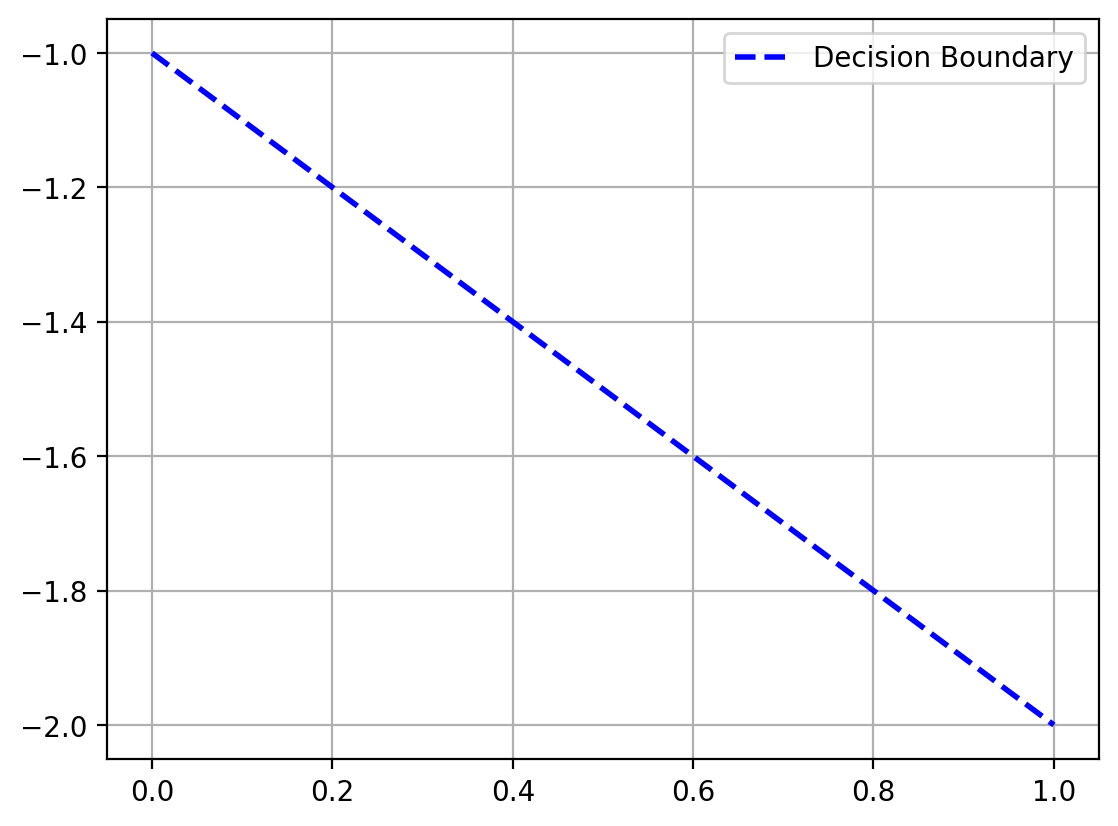

In [ ]:
# all weights and the bias are = 1
w1, w2, b = [1, 1, 1]
x1 = np.linspace(0, 1)
x2 = -(w1/w2)*x1 - (b/w2)
plt.plot(x1, x2, '--', c='blue', linewidth=2, label='Decision Boundary')
plt.grid()
plt.legend()
plt.show()

### The Perceptron as a binary Classifier

:::{note}
For the sake of simplicity we will have a look at a few examples in two- and three-dimensional space but keep in mind, that these concepts will work in higher dimensions as well.
:::

Now let's have a look at what we can do with our basic perceptron. One of the most fundamental examples of binary classifiers in two dimensions are the digital logic gates AND and OR. In this section we will build a perceptron for each of these logic gates and show how the decision boundary of our perceptron is affected by the weights and the bias.

The AND gate accepts two inputs and returns a binary output of either one or zero. We call the inputs $x_1$ and $x_2$ and the output $y$. AND behaves as denoted in the truth table and implements the mathematical conjunction $\land$. Only when both inputs $x_1$ and $x_2$ are equal to 1, will it return 1. Otherwise the output is always zero.

**AND Truth Table**  
|Input $(x_1,x_2)$|Output $y$|
|----|----|
|(0,0)|0|
|(0,1)|0|
|(1,0)|0|
|(1,1)|1|

Because we work in two-dimensional space we can interpret our input as a point in space and easily visualize these. We use black to draw points that generate an output of zero and red for points that generate an output of one.

array([0, 0, 1, 1])

array([0, 1, 0, 1])

array([0, 0, 0, 1])

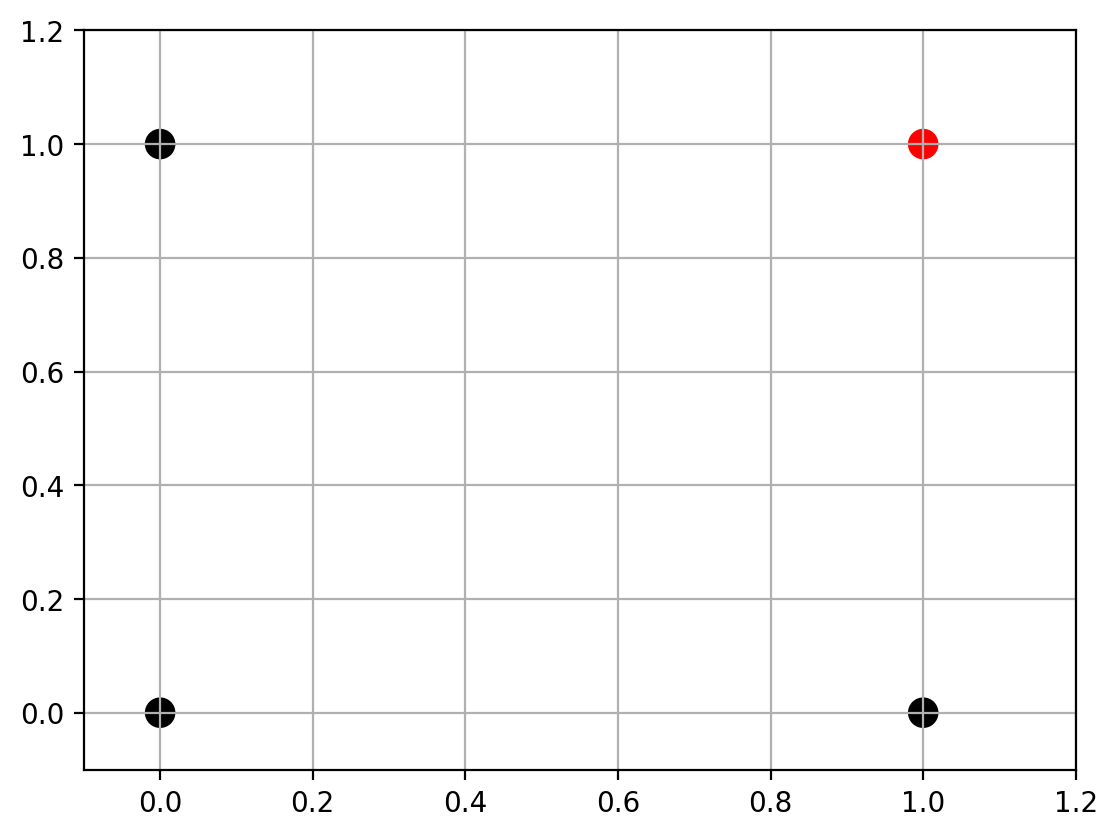

In [19]:
# coordinates of our points from the truth table
x1, x2 = np.array([[0,0], [0,1], [1,0], [1,1]]).T
# target labels (corresponding output from truth table)
y = np.array([0, 0, 0, 1])
display(x1, x2, y)
# map colors to target vector
colors = np.where(y == 1, "red", "black")
# plotting points in 2D
plt.scatter(x1, x2, c=colors, s=100)
plt.xlim((-0.1, 1.2))
plt.ylim((-0.1, 1.2))
plt.grid()
plt.show()

Before we can implement the AND gate, we go one step further with the code of our perceptron and remove the threshold. Instead of checking the weighted sum against a static threshold, we check it against 0 and move the decision boundary by adjusting our learnable parameters $w$ and $b$. We will go into the details of learning a bit later. For now just think of the weights and the bias as parameters we can adjust to change the output of our perceptron.

In [20]:
class perceptron:
    """
    A basic Perceptron implementation
    """

    def __init__(self, n_inputs):
        """ Initialize perceptron
        Parameters
        ----------
        n_inputs :  integer Size of input vector
        returns :   object  Perceptron object 
        """
       # init weights
        self.weights = rng.uniform(-1, 1, size=n_inputs + 1)
        # init weighted sum
        self.w_sum = 0
        # init output
        self.output = 0

    def fire(self):
        """ Check weighted sum against threshold of 0 and generate output.
        Parameters
        ----------
        returns : int    0 or 1
        """
        if self.w_sum >= 0:
            self.output = 1
            print("perceptron is firing")
            return 1
        else:
            self.output = 0
            print("perceptron is NOT firing")
            return 0

    def update(self, inputs):
        """ Update inputs, calculate weighted sum and generate output.
        Parameters
        ----------
        inputs : array_like     input vector  
        returns : int           0 or 1
        """
        # append bias term to weight vector and calculate weighted sum
        augmented_input = np.append(inputs, 1)
        self.w_sum = np.dot(augmented_input, self.weights)
        self.fire()

    def status(self):
        print(f"Weights: {self.weights}")
        print(f"Weighted sum: {self.w_sum}")
        print(f"Output: {self.output}")


Now that we have done that, we can initialize our AND-Perceptron and have a look at it.

In [24]:
and_perceptron = perceptron(2)
and_perceptron.status()

Weights: [-0.1131716  -0.54552256  0.10916957]
Weighted sum: 0
Output: 0


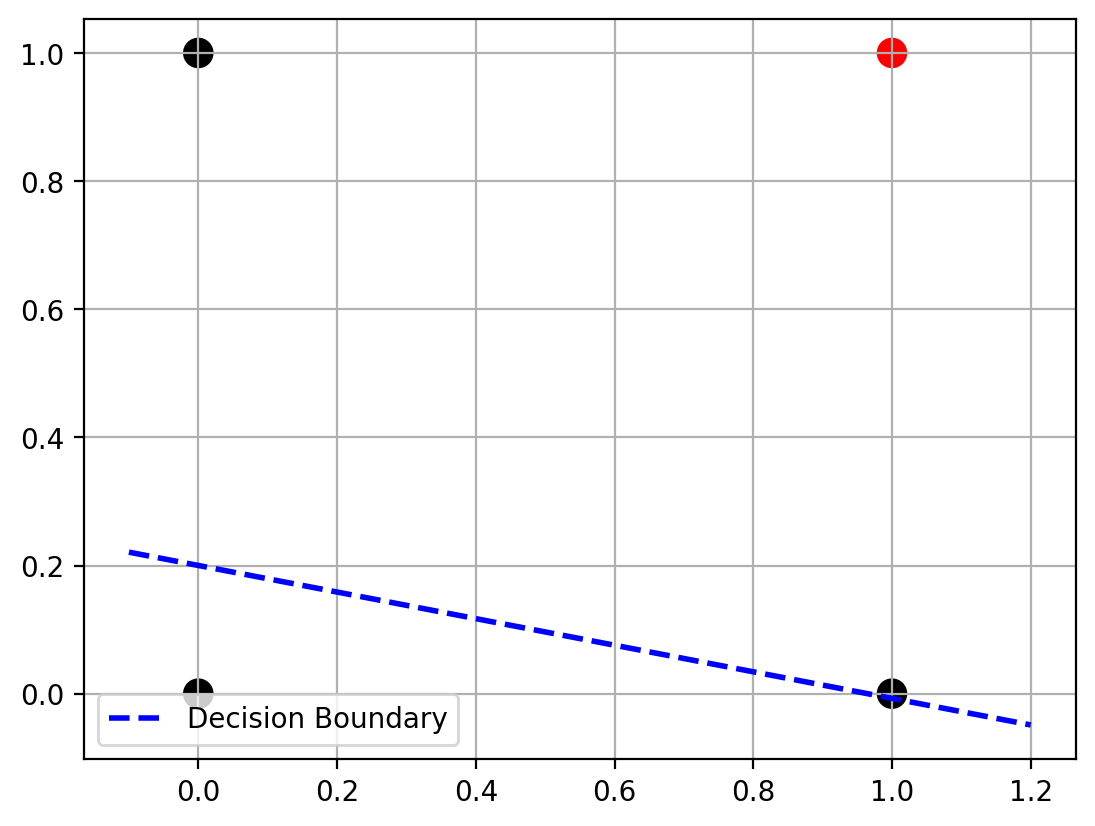

In [26]:
#extract weights and bias
w1, w2, b = and_perceptron.weights
# calculate decision boundary line
x_1 = np.linspace(-0.1, 1.2, 100)
x_2 = -(w1/w2)*x_1 - (b/w2)
# plotting points and decision boundary in 2D
plt.plot(x_1, x_2, '--', color='blue', linewidth=2, label='Decision Boundary')
plt.scatter(x1, x2, c=colors, s=100)
plt.grid()
plt.legend()
plt.show()

Wait, what happened now? Our Decision boundary is not even close to where we need it to be for it to correctly discriminate between the black and the red points. If you go back a bit, you might remember, that we initialized the weights and the bias as random values between -1 and 1. Now we want to find values that shift the boundary in a way, such that it is placed right between the red colored and black colored points. Because we will look at the learning - that is the self-adjusting of these parameters - in the next chapter, I will provide the right parameters for now: $w_1 = 1, w_2 = 1, b = -1.5$.  
We can now manually write them into our perceptron and regenerate the plot.

In [31]:
and_perceptron.weights = np.array([1, 1, -1.5])

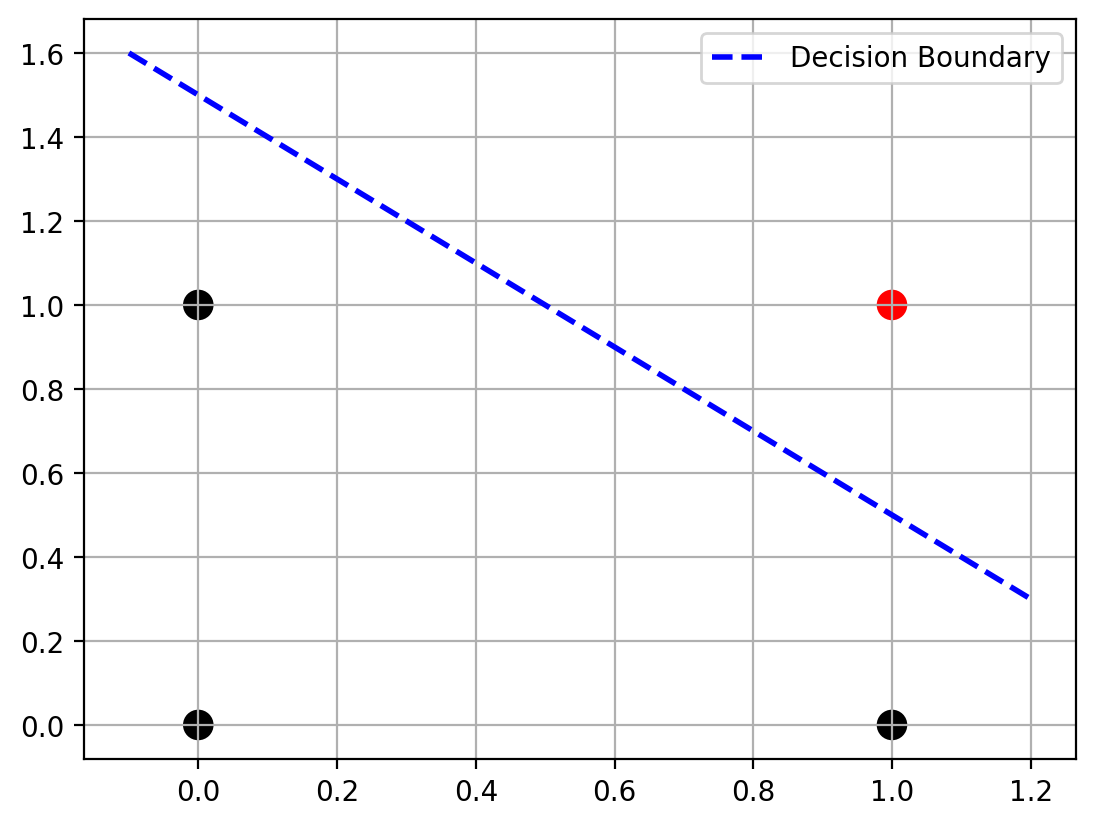

In [ ]:
#extract weights and bias
w1, w2, b = and_perceptron.weights
# calculate decision boundary line
x_1 = np.linspace(-0.1, 1.2, 100)
x_2 = -(w1/w2)*x_1 - (b/w2)
# plotting points and decision boundary in 2D
plt.plot(x_1, x_2, "--", color="blue", linewidth=2, label="Decision Boundary")
plt.scatter(x1, x2, c=colors, s=100)
plt.grid()
plt.legend()
plt.show()

The parameters we set, changed the decision boundary in a way that it perfectly implements the AND logic gate. But one question remains. **How** do the parameters affect the decision boundary. To analyse this, we have try to do the same thing but for the OR logic gate.

**OR Truth Table**  
|Input $(x_1,x_2)$|Output $y$|
|----|----|
|(0,0)|0|
|(0,1)|1|
|(1,0)|1|
|(1,1)|1|

OR behaves as denoted in the truth table and implements the mathematical disjunction $\lor$. If at least one of the inputs $x_1$ and $x_2$ is equal to 1, will it return 1. Otherwise the output is zero.  
Once again, we use a visualization to show the points in 2D. At the same time we plot the decision boundary of the AND gate to see how far we are of.

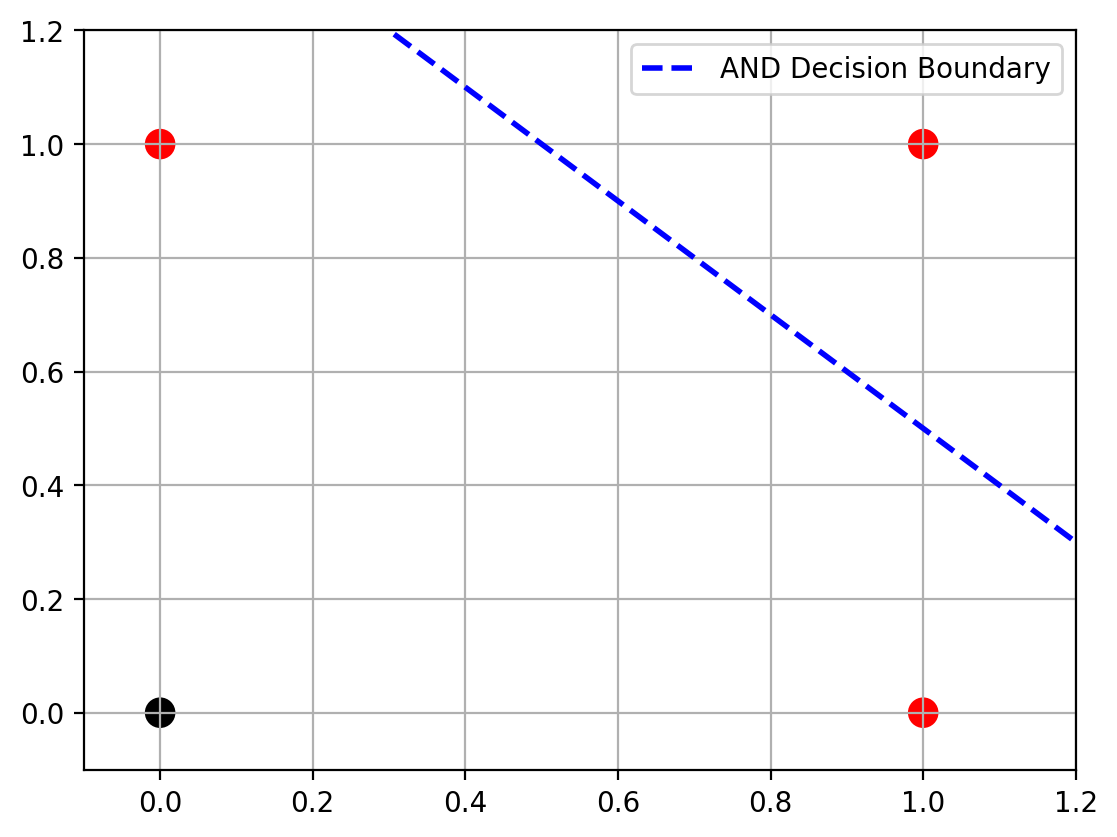

In [37]:
# coordinates of our points from the truth table
x1, x2 = np.array([[0,0], [0,1], [1,0], [1,1]]).T
# target labels (corresponding output from truth table)
y = np.array([0, 1, 1, 1])
# map colors to target vector
colors = np.where(y == 1, "red", "black")
# plotting points in 2D
plt.plot(x_1, x_2, '--', color="blue", linewidth=2, label="AND Decision Boundary")
plt.scatter(x1, x2, c=colors, s=100)
plt.xlim((-0.1, 1.2))
plt.ylim((-0.1, 1.2))
plt.legend()
plt.grid()
plt.show()

Now we need to define a linear function {eq}`eq-lin-function` that separates the two classes of points. We know that increasing $m$ increases the slope of a linear function. This causes the boundary to rotate counterclockwise. We also know that increasing $c$ lifts the boundary up (moves it upwards along the y-axis). We can se that the slope of the previous decision boundary seems to match our needs so we can concentrate on $c$. Moving the line down by a few units while keeping the slope would shift the boundary into the right place. For this to happen we need to decrease $c = - \frac{b}{w_2}$ while keeping $m = - \frac{w_1}{w_2}$ the same. This means, we can only adjust the bias because adjusting $w_2$ would also rotate the line. Let's try this out and increase $b$ so that $m$ will get smaller and we shift the boundary into the right place.

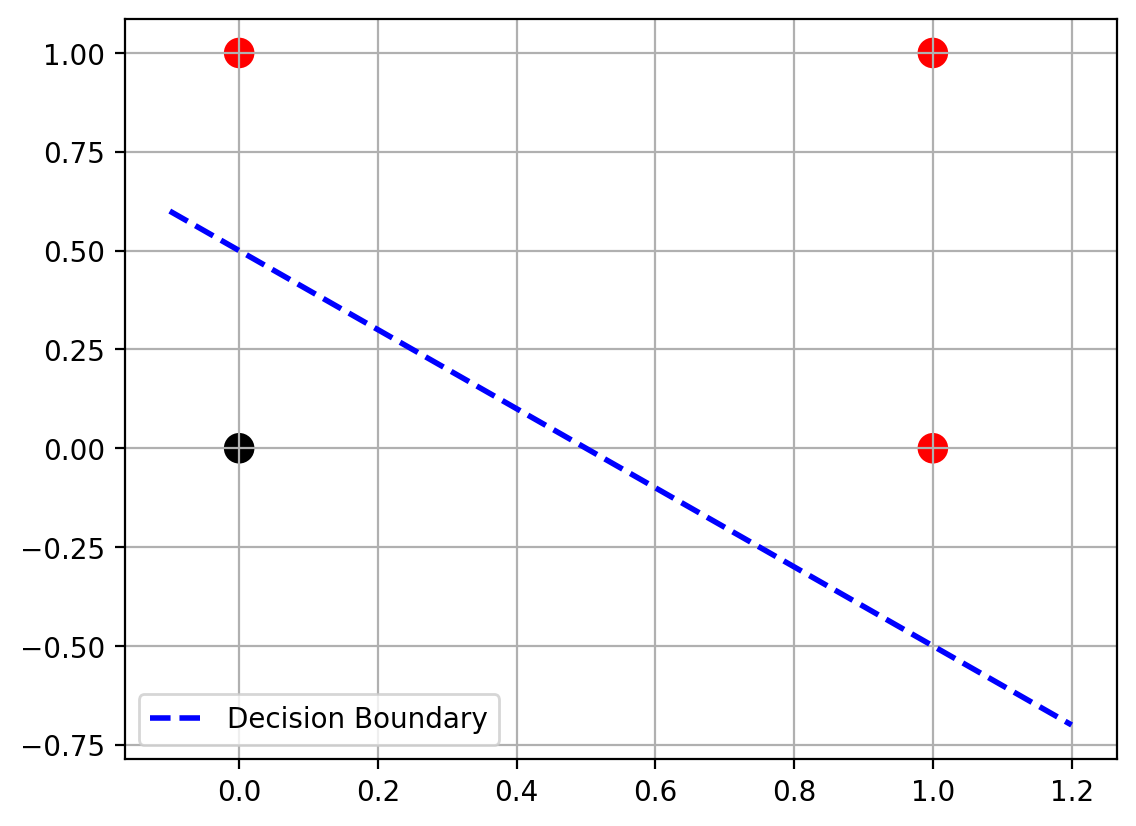

In [44]:
#define weights and bias
w1, w2, b = [1, 1, -0.5]
# calculate decision boundary line
x_1 = np.linspace(-0.1, 1.2, 100)
x_2 = -(w1/w2)*x_1 - (b/w2)
# plotting points and decision boundary in 2D
plt.plot(x_1, x_2, "--", color="blue", linewidth=2, label="Decision Boundary")
plt.scatter(x1, x2, c=colors, s=100)
plt.grid()
plt.legend()
plt.show()